In [ ]:
import seaborn as sns

# https://www.kaggle.com/competitions/titanic/data
df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# # Load Titanic (Seaborn CSV)
# url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
# df = pd.read_csv(url)


In [ ]:

# Keep only the requested "survived", "pclass", "sex", "age", "fare" columns
df = df[["survived", "pclass", "sex", "age", "fare"]].copy()


In [ ]:
df.shape

(891, 5)

In [ ]:
df.describe()

,survived,pclass,age,fare
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208
std,0.486592,0.836071,14.526497,49.693429
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,7.910400
50%,0.000000,3.000000,28.000000,14.454200
75%,1.000000,3.000000,38.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


In [ ]:
#  Handle missing values (Age has NaNs)
print(df["age"].isnull().sum())  # before
df["age"] = df["age"].fillna(df["age"].median())
print(df["age"].isnull().sum())  # after


177
0


In [ ]:
df.describe()

,survived,pclass,age,fare
count,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,32.204208
std,0.486592,0.836071,13.019697,49.693429
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,22.000000,7.910400
50%,0.000000,3.000000,28.000000,14.454200
75%,1.000000,3.000000,35.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


In [ ]:
df.head()

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [ ]:
df["sex"].unique()


array(['male', 'female'], dtype=object)

In [ ]:
# Encode sex (male/female -> 0/1)
df["sex"] = df["sex"].map({"male": 0, "female": 1})

In [ ]:
df.head()

,survived,pclass,sex,age,fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [ ]:
df["sex"].unique()

array([0, 1])

In [ ]:
df.duplicated().sum()

np.int64(128)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(763, 5)

In [ ]:
df.describe()

,survived,pclass,sex,age,fare
count,763.000000,763.000000,763.000000,763.000000,763.000000
mean,0.415465,2.238532,0.377457,29.602123,35.120527
std,0.493125,0.856186,0.485069,13.830570,52.735373
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,1.000000,0.000000,21.000000,8.050000
50%,0.000000,3.000000,0.000000,28.000000,16.000000
75%,1.000000,3.000000,1.000000,36.000000,34.375000
max,1.000000,3.000000,1.000000,80.000000,512.329200


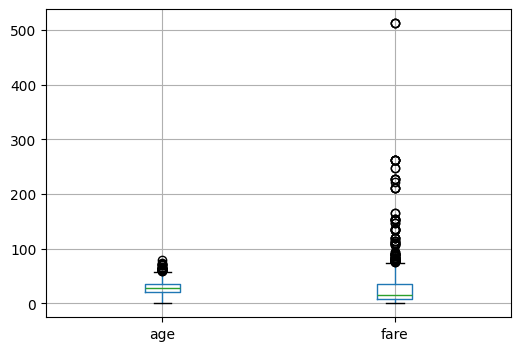

In [ ]:
import matplotlib.pyplot as plt

df[["age", "fare"]].boxplot(figsize=(6,4))
plt.show()


**Decision Trees are robust to outliers**

| Algorithm            | Remove outliers? |
|---------------------|------------------|
| Decision Tree       | ❌ No |
| Random Forest       | ❌ No |
| XGBoost             | ❌ No |
| KNN                 | ✅ Yes |
| K-Means             | ✅ Yes |
| Linear Regression   | ✅ Yes |
| Logistic Regression| ✅ Yes |
| SVM                 | ⚠️ Usually yes |


**you do NOT need to scale for Decision Trees.**

| Model | Scaling needed |
|---------------------|---------------|
| Decision Tree | ❌ No |
| Random Forest | ❌ No |
| XGBoost | ❌ No |
| KNN | ✅ Yes |
| Logistic Regression | ✅ Yes |
| SVM | ✅ Yes |
| Neural Network | ✅ Yes |


In [ ]:



#  Split features/target
X = df[["pclass", "sex", "age", "fare"]]
y = df["survived"]

#   Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Predict + evaluate
y_pred = clf.predict(X_test)

print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Train accuracy: 0.8081967213114755
Test accuracy : 0.7516339869281046

Confusion matrix:
 [[71 18]
 [20 44]]

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79        89
           1       0.71      0.69      0.70        64

    accuracy                           0.75       153
   macro avg       0.74      0.74      0.74       153
weighted avg       0.75      0.75      0.75       153



In [ ]:
train_acc = clf.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)

gap = (train_acc - test_acc) * 100

print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy : {test_acc*100:.2f}%")
print(f"Overfitting gap: {gap:.2f}%")


Train accuracy: 80.82%
Test accuracy : 75.16%
Overfitting gap: 5.66%


| Gap (%) | Meaning |
|--------|---------|
| < 3% | Very good / no overfitting |
| 3% – 7% | Mild overfitting |
| 7% – 12% | Moderate overfitting |
| > 12% | Strong overfitting |
| > 20% | Severe overfitting |
